<a href="https://colab.research.google.com/github/SinghBibushan/AI-and-ML/blob/main/worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

uploaded = files.upload()   # opens "Choose Files"
filename = next(iter(uploaded))  # gets the uploaded file name

img = Image.open(filename).convert("RGB")
img_array = np.array(img)

print("Image shape:", img_array.shape)

Saving cr7.jpg to cr7.jpg
Image shape: (1130, 1130, 3)


Saving cr7.jpg to cr7 (1).jpg
Grayscale image shape: (1130, 1130)


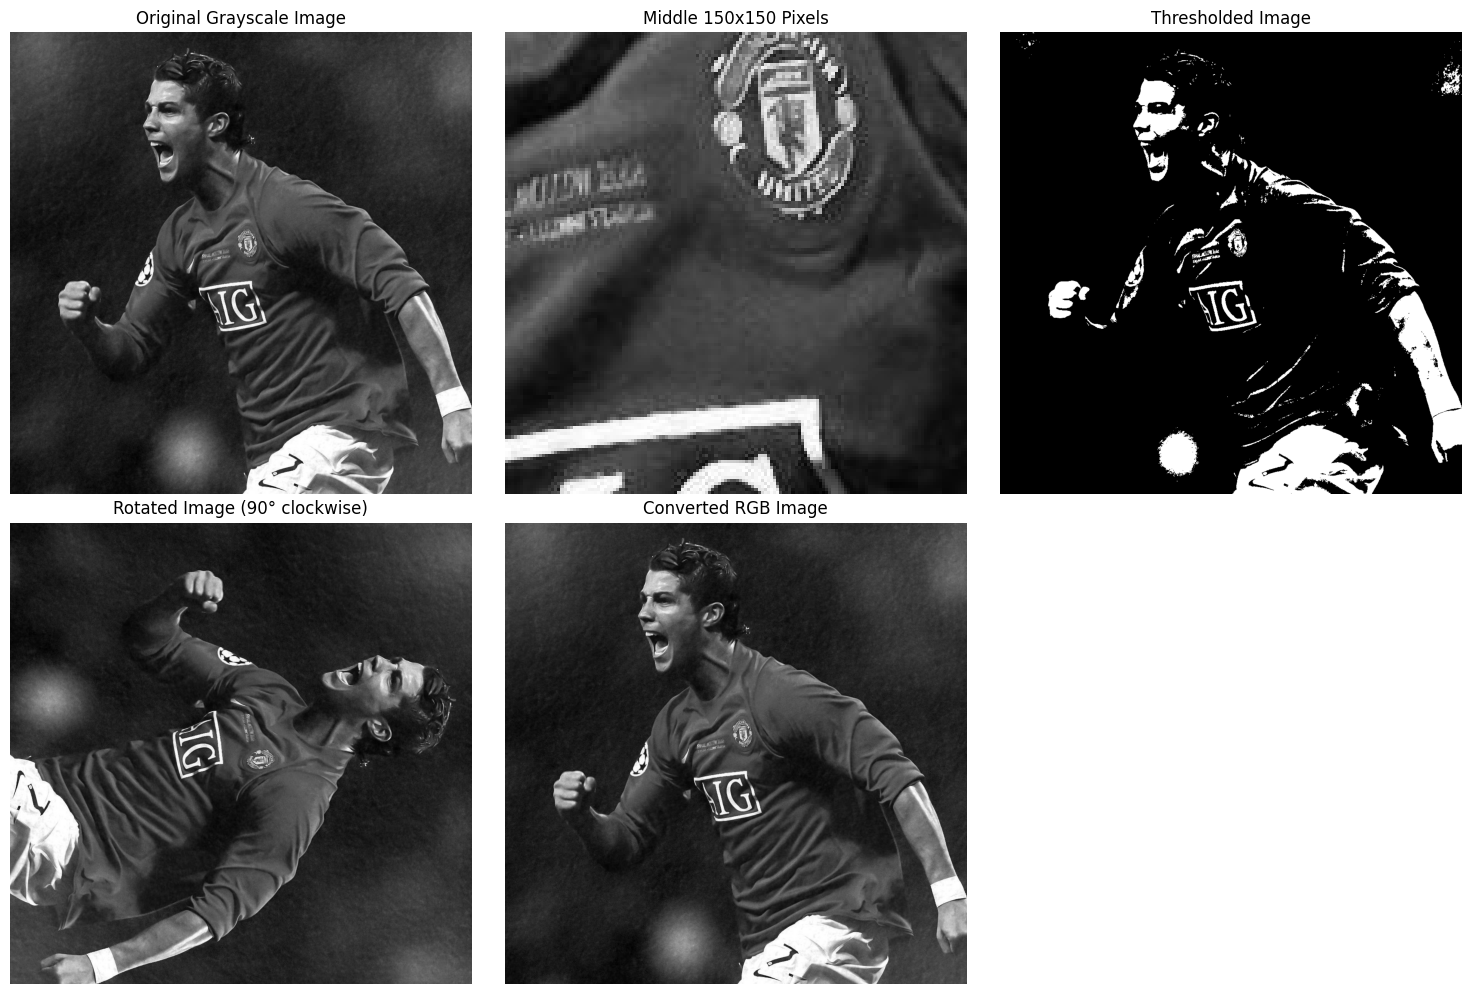

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Upload cameraman.png
uploaded = files.upload()
filename = next(iter(uploaded.keys()))

# Load cameraman as grayscale
img_gray = Image.open(filename).convert("L")
gray_array = np.array(img_gray)

print("Grayscale image shape:", gray_array.shape)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Original grayscale
axes[0, 0].imshow(gray_array, cmap="gray")
axes[0, 0].set_title("Original Grayscale Image")
axes[0, 0].axis("off")

# 2. Middle 150x150 section
h, w = gray_array.shape
mid_h, mid_w = h // 2, w // 2
middle = gray_array[mid_h - 75 : mid_h + 75, mid_w - 75 : mid_w + 75]
axes[0, 1].imshow(middle, cmap="gray")
axes[0, 1].set_title("Middle 150x150 Pixels")
axes[0, 1].axis("off")

# 3. Threshold: below 100 → 0, above 100 → 255
thresholded = np.where(gray_array < 100, 0, 255).astype(np.uint8)
axes[0, 2].imshow(thresholded, cmap="gray")
axes[0, 2].set_title("Thresholded Image")
axes[0, 2].axis("off")

# 4. Rotate 90 degrees clockwise
rotated = img_gray.rotate(-90, expand=True)
axes[1, 0].imshow(np.array(rotated), cmap="gray")
axes[1, 0].set_title("Rotated Image (90° clockwise)")
axes[1, 0].axis("off")

# 5. Convert grayscale to RGB
rgb_from_gray = np.stack([gray_array, gray_array, gray_array], axis=-1)
axes[1, 1].imshow(rgb_from_gray)
axes[1, 1].set_title("Converted RGB Image")
axes[1, 1].axis("off")

# Hide unused subplot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

Saving cr7.jpg to cr7 (2).jpg
Image shape       : (1130, 1130)
Pixel value range : 0.0 – 255.0

Standardised data — mean ≈ -0.0  std ≈ 1.0
Covariance matrix shape: (1130, 1130)


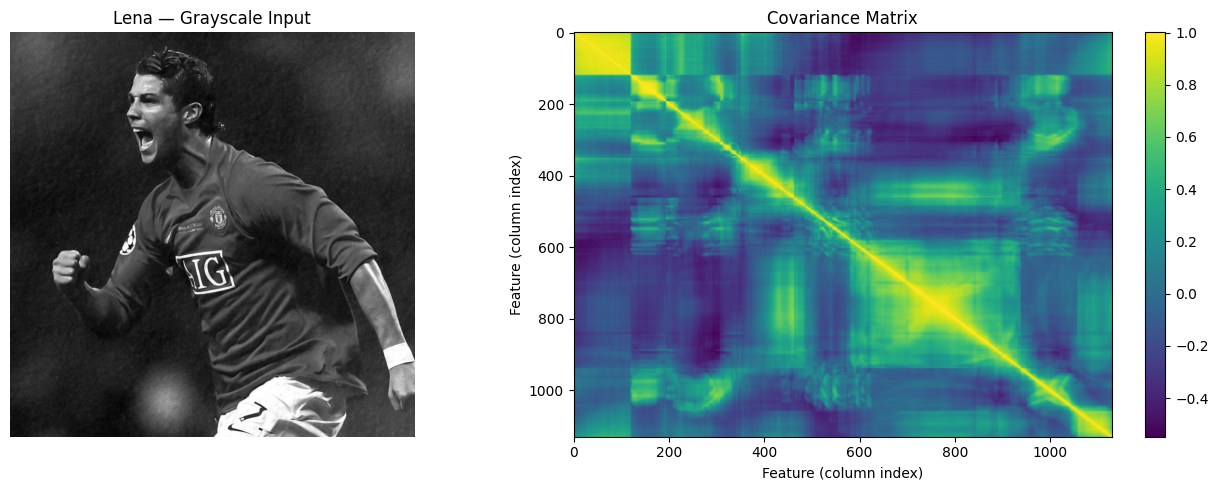

Top 10 eigenvalues: [291.93 159.81  99.22  91.64  58.54  41.9   34.49  31.56  23.02  18.7 ]
Eigenvectors shape : (1130, 1130)

Components needed for each variance threshold:
  80%  →  14 components
  90%  →  29 components
  95%  →  55 components
  99%  →  187 components


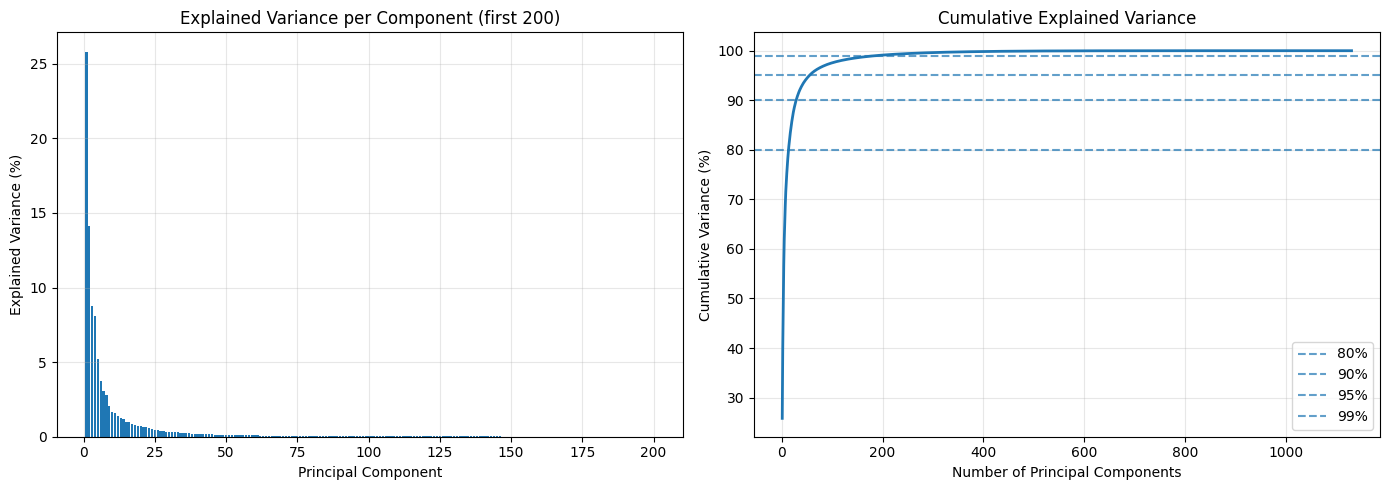

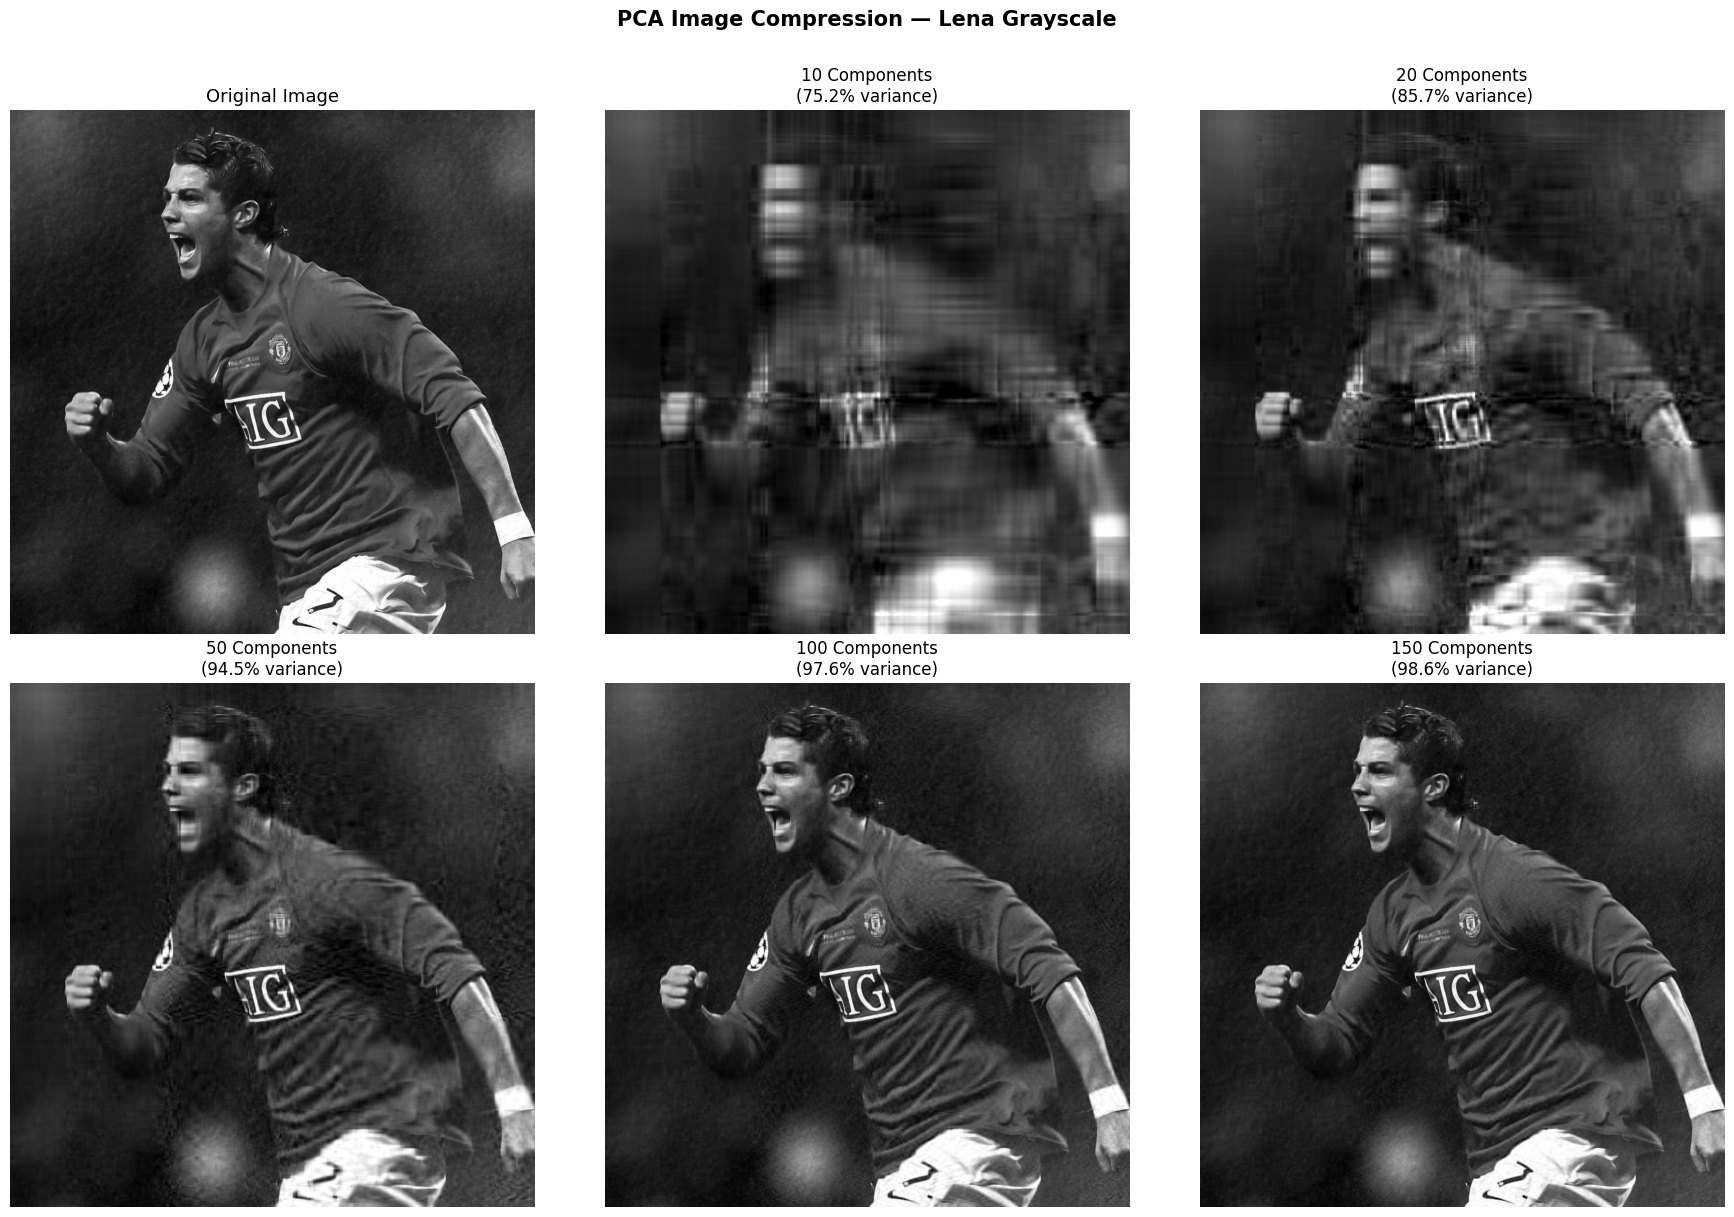


     k |   Explained Var |    Orig Size |   Compressed |    Ratio
--------------------------------------------------------------
    10 |          75.23% |    1,276,900 |       22,610 |   56.48x
    20 |          85.72% |    1,276,900 |       45,220 |   28.24x
    50 |          94.46% |    1,276,900 |      113,050 |   11.30x
   100 |          97.56% |    1,276,900 |      226,100 |    5.65x
   150 |          98.59% |    1,276,900 |      339,150 |    3.77x


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# Upload lena_gray.gif
uploaded = files.upload()
filename = next(iter(uploaded.keys()))

# Load lena_gray as float grayscale
img = Image.open(filename).convert("L")
img_array = np.array(img, dtype=np.float64)

print("Image shape       :", img_array.shape)
print("Pixel value range :", img_array.min(), "–", img_array.max())

# Step 1: Standardise the data
mean = np.mean(img_array, axis=0)
std = np.std(img_array, axis=0) + 1e-8
X_std = (img_array - mean) / std

print("\nStandardised data — mean ≈", np.round(X_std.mean(), 6),
      " std ≈", np.round(X_std.std(), 4))

# Step 2: Covariance matrix
n = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n - 1)

print("Covariance matrix shape:", cov_matrix.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_array, cmap="gray")
axes[0].set_title("Lena — Grayscale Input")
axes[0].axis("off")

axes[1].imshow(cov_matrix, cmap="viridis", aspect="auto")
axes[1].set_title("Covariance Matrix")
axes[1].set_xlabel("Feature (column index)")
axes[1].set_ylabel("Feature (column index)")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

# Step 3: Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Top 10 eigenvalues:", np.round(eigenvalues[:10], 2))
print("Eigenvectors shape :", eigenvectors.shape)

# Step 4: Explained variance
total_var = np.sum(eigenvalues)
explained_var = eigenvalues / total_var
cumulative_var = np.cumsum(explained_var)

print("\nComponents needed for each variance threshold:")
for threshold in [0.80, 0.90, 0.95, 0.99]:
    k = np.searchsorted(cumulative_var, threshold) + 1
    print(f"  {int(threshold*100)}%  →  {k} components")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 201), explained_var[:200] * 100)
axes[0].set_title("Explained Variance per Component (first 200)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, linewidth=2)
for threshold in [80, 90, 95, 99]:
    axes[1].axhline(y=threshold, linestyle="--", alpha=0.7, label=f"{threshold}%")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

def pca_reconstruct(X_std, eigenvectors, mean, std, k):
    W_k = eigenvectors[:, :k]
    Z = X_std @ W_k
    X_rec_std = Z @ W_k.T
    X_rec = X_rec_std * std + mean
    return np.clip(X_rec, 0, 255).astype(np.uint8)

# Reconstruction with different k values
k_values = [10, 20, 50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

axes[0].imshow(img_array, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original Image", fontsize=13)
axes[0].axis("off")

for i, k in enumerate(k_values, start=1):
    reconstructed = pca_reconstruct(X_std, eigenvectors, mean, std, k)
    exp_var_k = cumulative_var[k - 1] * 100

    axes[i].imshow(reconstructed, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(f"{k} Components\n({exp_var_k:.1f}% variance)", fontsize=12)
    axes[i].axis("off")

plt.suptitle("PCA Image Compression — Lena Grayscale",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Summary table
H, W = img_array.shape
print(f"\n{'k':>6} | {'Explained Var':>15} | {'Orig Size':>12} | {'Compressed':>12} | {'Ratio':>8}")
print("-" * 62)
for k in k_values:
    exp_var_k = cumulative_var[k - 1] * 100
    original_size = H * W
    compressed_size = k * (H + W + 1)
    ratio = original_size / compressed_size
    print(f"{k:>6} | {exp_var_k:>14.2f}% | {original_size:>12,} | {compressed_size:>12,} | {ratio:>7.2f}x")